# Intel Image Classification - 5 CNN Techniques Comparison

This Colab notebook runs 5 experiments on the Intel Image Classification dataset:

1. Basic CNN (from scratch)
2. Basic CNN + Data Augmentation
3. Pretrained VGG16 (frozen conv base + trained classifier)
4. Feature Extraction (VGG16 frozen -> features -> small classifier)
5. Fine Tuning (unfreeze top VGG16 block + classifier)

It also produces:
- training curves for each experiment
- test evaluation
- confusion matrix
- classification report
- summary table of results


## 1) Runtime and dataset setup

Upload or mount your dataset so that one of these folder layouts exists under `DATA_ROOT`:

- `seg_train/seg_train` and `seg_test/seg_test`
- `seg_train/seg_train` and `seg_test`
- `seg_train` and `seg_test`
- `train` and `test`
- `Training` and `Testing`

Example Google Drive path:
`/content/drive/MyDrive/intel-image-classification-data`


In [2]:
# Optional: mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Install dependencies if needed
!pip -q install tensorflow scikit-learn pandas matplotlib


In [4]:
from __future__ import annotations

import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.19.0


In [5]:
@dataclass(frozen=True)
class Config:
    data_root: Path
    img_size: Tuple[int, int] = (160, 160)
    batch_size: int = 32
    seed: int = 42
    val_split: float = 0.2
    epochs: int = 8
    patience: int = 3
    base_lr: float = 1e-3
    finetune_lr: float = 1e-5

# CHANGE THIS to your dataset folder in Colab / Drive
DATA_ROOT = Path('/content/drive/MyDrive/intel-image-classification-data')
CFG = Config(data_root=DATA_ROOT)
print('DATA_ROOT:', CFG.data_root)


DATA_ROOT: /content/drive/MyDrive/intel-image-classification-data


In [6]:
def resolve_dataset_dirs(data_root: Path) -> Tuple[Path, Path]:
    candidates = [
        (data_root / 'seg_train' / 'seg_train', data_root / 'seg_test' / 'seg_test'),
        (data_root / 'seg_train' / 'seg_train', data_root / 'seg_test'),
        (data_root / 'seg_train', data_root / 'seg_test'),
        (data_root / 'train', data_root / 'test'),
        (data_root / 'Training', data_root / 'Testing'),
    ]

    def looks_like_class_dir(p: Path) -> bool:
        if not p.exists() or not p.is_dir():
            return False
        subdirs = [d for d in p.iterdir() if d.is_dir()]
        return len(subdirs) >= 2

    for train_dir, test_dir in candidates:
        if looks_like_class_dir(train_dir) and looks_like_class_dir(test_dir):
            return train_dir, test_dir

    tried = '\n'.join([f'- {tr[0]} | {tr[1]}' for tr in candidates])
    raise FileNotFoundError(
        'Could not find dataset folders.\n'
        f'data_root: {data_root.resolve()}\n'
        f'Tried:\n{tried}\n'
        'Expected class folders like: buildings/ forest/ glacier/ mountain/ sea/ street/'
    )

TRAIN_DIR, TEST_DIR = resolve_dataset_dirs(CFG.data_root)
print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR:', TEST_DIR)


TRAIN_DIR: /content/drive/MyDrive/intel-image-classification-data/seg_train/seg_train
TEST_DIR: /content/drive/MyDrive/intel-image-classification-data/seg_test/seg_test


In [7]:
def make_datasets(
    train_dir: Path,
    test_dir: Path,
    img_size: Tuple[int, int],
    batch_size: int,
    seed: int,
    val_split: float,
) -> Tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, List[str]]:
    train_ds = keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=val_split,
        subset='training',
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
    )
    val_ds = keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=val_split,
        subset='validation',
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
    )
    test_ds = keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=False,
    )

    class_names = train_ds.class_names
    autotune = tf.data.AUTOTUNE

    def perf(ds: tf.data.Dataset) -> tf.data.Dataset:
        return ds.cache().prefetch(buffer_size=autotune)

    return perf(train_ds), perf(val_ds), perf(test_ds), class_names

train_ds, val_ds, test_ds, class_names = make_datasets(
    TRAIN_DIR, TEST_DIR, CFG.img_size, CFG.batch_size, CFG.seed, CFG.val_split
)
NUM_CLASSES = len(class_names)
print('Classes:', class_names)


Found 14047 files belonging to 6 classes.
Using 11238 files for training.
Found 14047 files belonging to 6 classes.
Using 2809 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [8]:
def plot_history(history: keras.callbacks.History, title: str) -> None:
    metrics = history.history

    plt.figure(figsize=(6, 4))
    plt.plot(metrics.get('accuracy', []), label='train')
    plt.plot(metrics.get('val_accuracy', []), label='val')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(metrics.get('loss', []), label='train')
    plt.plot(metrics.get('val_loss', []), label='val')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def ds_to_numpy(ds: tf.data.Dataset) -> Tuple[np.ndarray, np.ndarray]:
    xs, ys = [], []
    for x, y in ds:
        xs.append(x.numpy())
        ys.append(y.numpy())
    return np.concatenate(xs, axis=0), np.concatenate(ys, axis=0)


def plot_confusion(y_true: List[int], y_pred: List[int], class_names: List[str], title: str) -> None:
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.show()


def evaluate_model(
    model: keras.Model,
    test_ds: tf.data.Dataset,
    class_names: List[str],
    title: str,
    history: Optional[keras.callbacks.History] = None,
) -> Dict[str, float]:
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true = []
    y_pred = []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch.numpy(), axis=1).tolist())
        y_pred.extend(np.argmax(preds, axis=1).tolist())

    train_acc = None
    val_acc = None
    if history is not None:
        train_acc = max(history.history.get("accuracy", [None]))
        val_acc = max(history.history.get("val_accuracy", [None]))

    print(f'\n=== {title} ===')
    if train_acc is not None and val_acc is not None:
        print(
            f'Train accuracy: {train_acc:.4f} | '
            f'Validation accuracy: {val_acc:.4f} | '
            f'Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}'
        )
    else:
        print(f'Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}')

    plot_confusion(y_true, y_pred, class_names, f'{title} - Confusion Matrix')
    print('\nClassification report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names))

    return {
        'train_accuracy': float(train_acc) if train_acc is not None else None,
        'validation_accuracy': float(val_acc) if val_acc is not None else None,
        'test_accuracy': float(test_acc),
        'test_loss': float(test_loss),
    }


def compile_and_train(
    model: keras.Model,
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    lr: float,
    epochs: int,
    patience: int,
    tag: str,
) -> keras.callbacks.History:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(1, patience // 2), verbose=1),
        keras.callbacks.ModelCheckpoint(f'/content/best_{tag}.keras', monitor='val_accuracy', save_best_only=True),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )
    return history


In [9]:
def build_basic_cnn(num_classes: int, img_size: Tuple[int, int], augment: Optional[keras.Model] = None) -> keras.Model:
    inputs = keras.Input(shape=(img_size[0], img_size[1], 3))
    x = inputs

    if augment is not None:
        x = augment(x)

    x = layers.Rescaling(1.0 / 255.0)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='basic_cnn')


def make_augmentation() -> keras.Model:
    return keras.Sequential(
        [
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.1, 0.1),
        ],
        name='augmentation',
    )


def build_vgg16_classifier(
    num_classes: int,
    img_size: Tuple[int, int],
    base_trainable: bool,
    augment: Optional[keras.Model] = None,
) -> Tuple[keras.Model, keras.Model]:
    inputs = keras.Input(shape=(img_size[0], img_size[1], 3))
    x = inputs

    if augment is not None:
        x = augment(x)

    x = tf.keras.applications.vgg16.preprocess_input(x)

    base_model = tf.keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size[0], img_size[1], 3),
    )
    base_model.trainable = base_trainable

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='vgg16_transfer')
    return model, base_model


def build_feature_extractor(img_size: Tuple[int, int]) -> keras.Model:
    inputs = keras.Input(shape=(img_size[0], img_size[1], 3))
    x = tf.keras.applications.vgg16.preprocess_input(inputs)
    base = tf.keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size[0], img_size[1], 3),
        pooling='avg',
    )
    base.trainable = False
    outputs = base(x, training=False)
    return keras.Model(inputs, outputs, name='vgg16_feature_extractor')


def build_feature_classifier(num_classes: int, feature_dim: int) -> keras.Model:
    inputs = keras.Input(shape=(feature_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='feature_classifier')


Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 422s 1s/step - accuracy: 0.6135 - loss: 0.9970 - val_accuracy: 0.7323 - val_loss: 0.7186 - learning_rate: 0.0010
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7472 - loss: 0.6895 - val_accuracy: 0.7679 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7956 - loss: 0.5559 - val_accuracy: 0.7925 - val_loss: 0.5763 - learning_rate: 0.0010
Epoch 4/8
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8266 - loss: 0.4824
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8432 - loss: 0.4354 - val_accuracy: 0.7910 - val_loss: 0.6273 - learning_rate: 0.0010
Epoch 5/8
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8818 - loss: 0.3450
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8923 - loss: 0.305

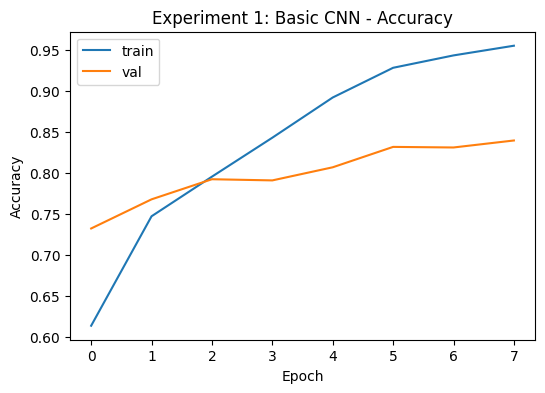

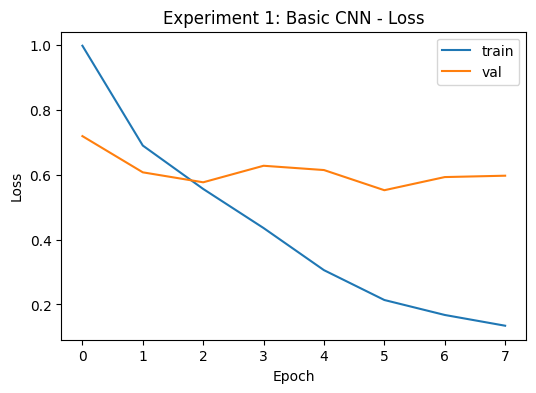


=== Experiment 1: Basic CNN ===
Train accuracy: 0.9556 | Validation accuracy: 0.8398 | Test accuracy: 0.8397 | Test loss: 0.6249


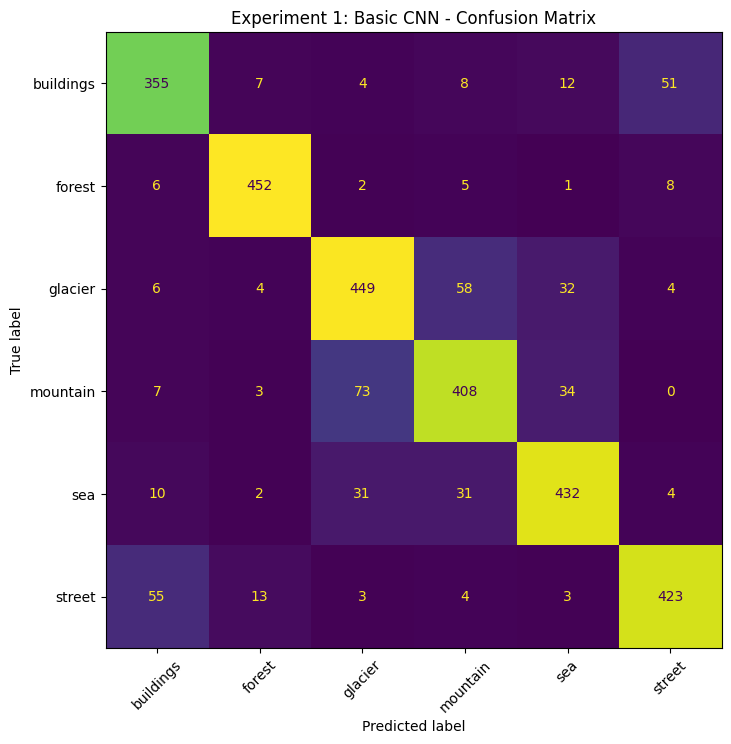


Classification report:

              precision    recall  f1-score   support

   buildings       0.81      0.81      0.81       437
      forest       0.94      0.95      0.95       474
     glacier       0.80      0.81      0.81       553
    mountain       0.79      0.78      0.79       525
         sea       0.84      0.85      0.84       510
      street       0.86      0.84      0.85       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



In [10]:
results: List[Dict[str, object]] = []

# 1) Basic CNN
model1 = build_basic_cnn(NUM_CLASSES, CFG.img_size, augment=None)
hist1 = compile_and_train(
    model1, train_ds, val_ds, lr=CFG.base_lr, epochs=CFG.epochs, patience=CFG.patience, tag='exp1_basic_cnn'
)
plot_history(hist1, 'Experiment 1: Basic CNN')
eval1 = evaluate_model(model1, test_ds, class_names, "Experiment 1: Basic CNN", history=hist1)
results.append({'experiment': '1) Basic CNN', **eval1})

Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5511 - loss: 1.1432 - val_accuracy: 0.6632 - val_loss: 0.8480 - learning_rate: 0.0010
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.6668 - loss: 0.8916 - val_accuracy: 0.7109 - val_loss: 0.7611 - learning_rate: 0.0010
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.7024 - loss: 0.8104 - val_accuracy: 0.7344 - val_loss: 0.7054 - learning_rate: 0.0010
Epoch 4/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.7274 - loss: 0.7522 - val_accuracy: 0.7487 - val_loss: 0.6562 - learning_rate: 0.0010
Epoch 5/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.7427 - loss: 0.7098 - val_accuracy: 0.7665 - val_loss: 0.6176 - learning_rate: 0.0010
Epoch 6/8
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7527 - loss: 0.6978
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.7604 - loss: 0.6

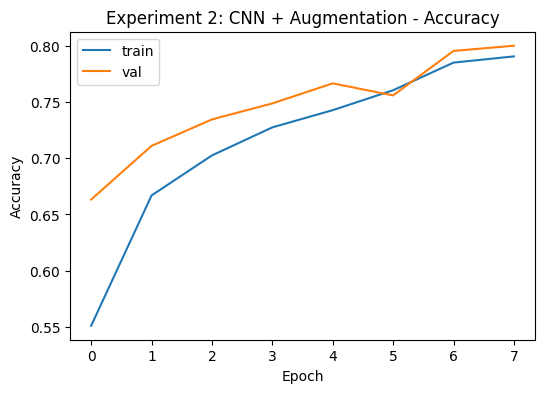

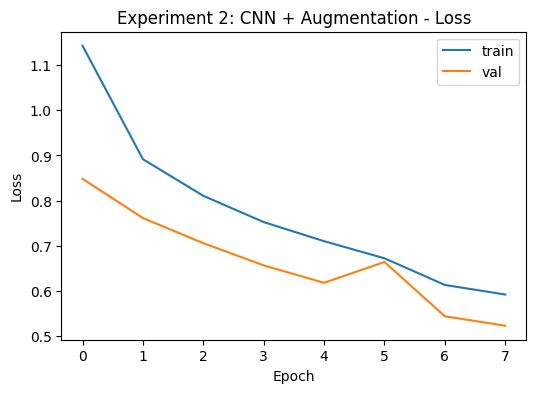


=== Experiment 2: CNN + Augmentation ===
Train accuracy: 0.7904 | Validation accuracy: 0.7999 | Test accuracy: 0.8127 | Test loss: 0.5199


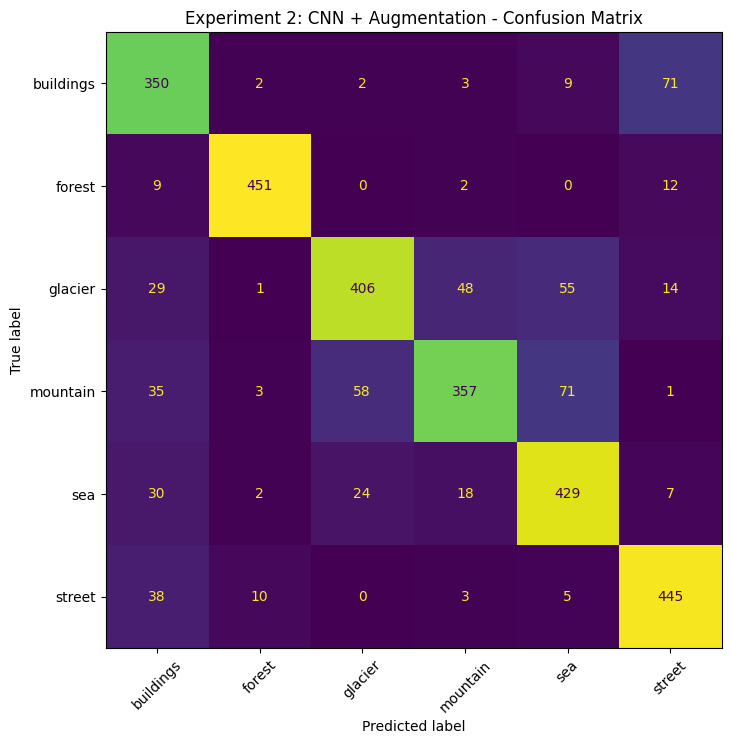


Classification report:

              precision    recall  f1-score   support

   buildings       0.71      0.80      0.75       437
      forest       0.96      0.95      0.96       474
     glacier       0.83      0.73      0.78       553
    mountain       0.83      0.68      0.75       525
         sea       0.75      0.84      0.80       510
      street       0.81      0.89      0.85       501

    accuracy                           0.81      3000
   macro avg       0.82      0.82      0.81      3000
weighted avg       0.82      0.81      0.81      3000



In [11]:
# 2) CNN + Data Augmentation
augment = make_augmentation()
model2 = build_basic_cnn(NUM_CLASSES, CFG.img_size, augment=augment)
hist2 = compile_and_train(
    model2, train_ds, val_ds, lr=CFG.base_lr, epochs=CFG.epochs, patience=CFG.patience, tag='exp2_aug_cnn'
)
plot_history(hist2, 'Experiment 2: CNN + Augmentation')
eval2 = evaluate_model(model2, test_ds, class_names, "Experiment 2: CNN + Augmentation", history=hist2)
results.append({'experiment': '2) CNN + Augmentation', **eval2})


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 75s 181ms/step - accuracy: 0.8468 - loss: 0.6392 - val_accuracy: 0.9188 - val_loss: 0.2519 - learning_rate: 0.0010
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.9048 - loss: 0.2774 - val_accuracy: 0.9192 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 3/8
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9193 - loss: 0.2385
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.9224 - loss: 0.2194 - val_accuracy: 0.9199 - val_loss: 0.2398 - learning_rate: 0.0010
Epoch 4/8
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9356 - loss: 0.1839
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.9385 - loss: 0.1699 - val_accuracy: 0.9249 - val_loss: 0.2297 - learning_rate: 5.0000e-04
Epoch 5/8
351/352 ━━━━━

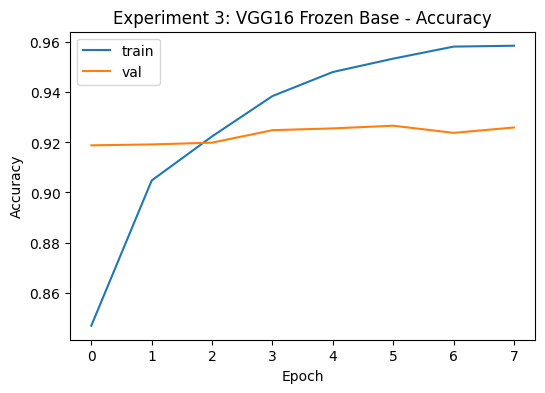

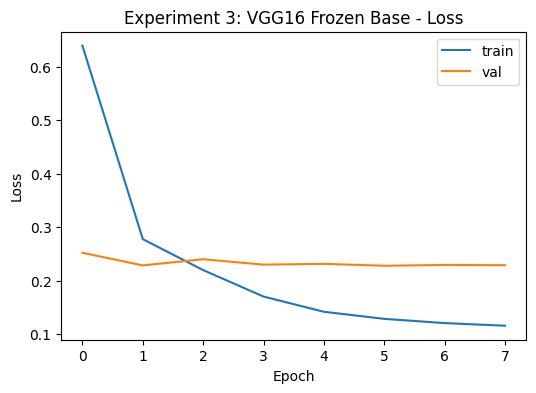


=== Experiment 3: VGG16 Frozen Base ===
Train accuracy: 0.9586 | Validation accuracy: 0.9267 | Test accuracy: 0.9137 | Test loss: 0.2524


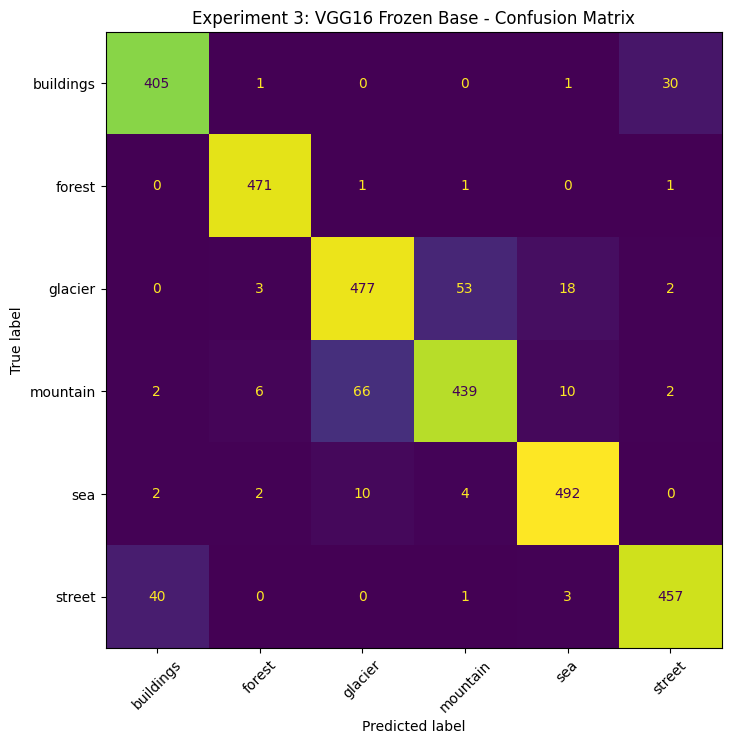


Classification report:

              precision    recall  f1-score   support

   buildings       0.90      0.93      0.91       437
      forest       0.98      0.99      0.98       474
     glacier       0.86      0.86      0.86       553
    mountain       0.88      0.84      0.86       525
         sea       0.94      0.96      0.95       510
      street       0.93      0.91      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.92      0.92      3000
weighted avg       0.91      0.91      0.91      3000



In [12]:
# 3) Pretrained VGG16 (freeze conv base, train classifier)
model3, base3 = build_vgg16_classifier(NUM_CLASSES, CFG.img_size, base_trainable=False, augment=None)
hist3 = compile_and_train(
    model3, train_ds, val_ds, lr=CFG.base_lr, epochs=CFG.epochs, patience=CFG.patience, tag='exp3_vgg16_frozen'
)
plot_history(hist3, 'Experiment 3: VGG16 Frozen Base')
eval3 = evaluate_model(model3, test_ds, class_names, "Experiment 3: VGG16 Frozen Base", history=hist3)
results.append({'experiment': '3) VGG16 Frozen Base', **eval3})


352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step
Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8461 - loss: 0.6090 - val_accuracy: 0.8985 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 2/8
336/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8979 - loss: 0.2858
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9024 - loss: 0.2724 - val_accuracy: 0.9021 - val_loss: 0.2854 - learning_rate: 0.0010
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9288 - loss: 0.2013 - val_accuracy: 0.9178 - val_loss: 0.2251 - learning_rate: 5.0000e-04
Epoch 4/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9387 - loss: 0.1769 - val_accuracy: 0.9245 - val_loss: 0.2216 - learning_rate: 5.0000e-04
Epoch 5/8
342/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9470 - loss: 0.1490
Epoch 5: ReduceLROnPlate

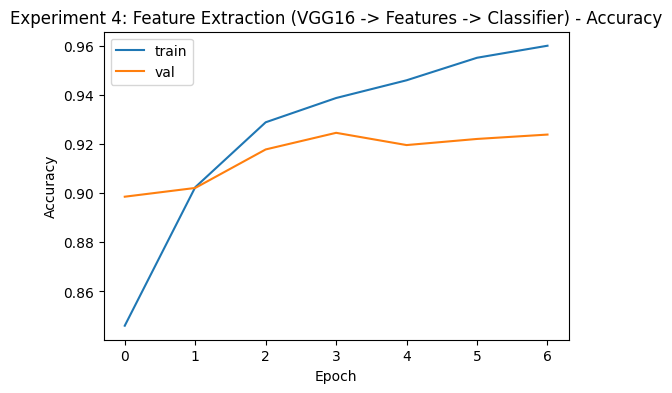

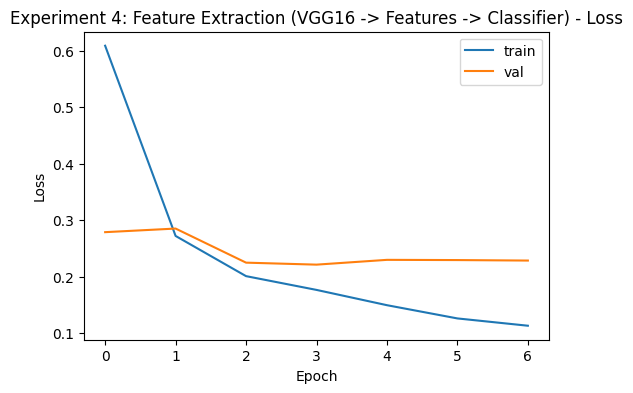


=== Experiment 4: Feature Extraction ===
Train accuracy: 0.9600 | Validation accuracy: 0.9245 | Test accuracy: 0.9097 | Test loss: 0.2557


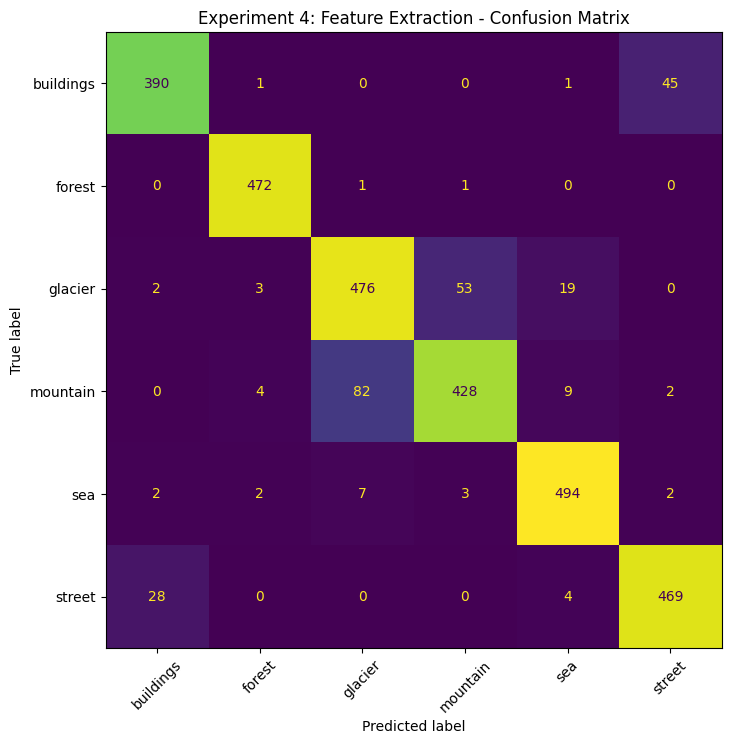


Classification report:

              precision    recall  f1-score   support

   buildings       0.92      0.89      0.91       437
      forest       0.98      1.00      0.99       474
     glacier       0.84      0.86      0.85       553
    mountain       0.88      0.82      0.85       525
         sea       0.94      0.97      0.95       510
      street       0.91      0.94      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



In [13]:
# 4) Feature Extraction (VGG16 frozen -> feature vectors -> classifier)
feature_extractor = build_feature_extractor(CFG.img_size)

X_train, y_train = ds_to_numpy(train_ds)
X_val, y_val = ds_to_numpy(val_ds)
X_test, y_test = ds_to_numpy(test_ds)

train_feats = feature_extractor.predict(X_train, batch_size=CFG.batch_size, verbose=1)
val_feats = feature_extractor.predict(X_val, batch_size=CFG.batch_size, verbose=1)
test_feats = feature_extractor.predict(X_test, batch_size=CFG.batch_size, verbose=1)

feat_dim = train_feats.shape[1]
clf4 = build_feature_classifier(NUM_CLASSES, feat_dim)

clf4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CFG.base_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks4 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=CFG.patience, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(1, CFG.patience // 2), verbose=1),
    keras.callbacks.ModelCheckpoint('/content/best_exp4_feature_extraction.keras', monitor='val_accuracy', save_best_only=True),
]

hist4 = clf4.fit(
    train_feats,
    y_train,
    validation_data=(val_feats, y_val),
    epochs=CFG.epochs,
    callbacks=callbacks4,
    verbose=1,
)
plot_history(hist4, 'Experiment 4: Feature Extraction (VGG16 -> Features -> Classifier)')

test_loss4, test_acc4 = clf4.evaluate(test_feats, y_test, verbose=0)
y_true4 = np.argmax(y_test, axis=1)
y_pred4 = np.argmax(clf4.predict(test_feats, verbose=0), axis=1)
train_acc4 = max(hist4.history.get("accuracy", [None]))
val_acc4 = max(hist4.history.get("val_accuracy", [None]))
print('\n=== Experiment 4: Feature Extraction ===')
print(
    f"Train accuracy: {train_acc4:.4f} | "
    f"Validation accuracy: {val_acc4:.4f} | "
    f"Test accuracy: {test_acc4:.4f} | Test loss: {test_loss4:.4f}"
)
plot_confusion(y_true4, y_pred4, class_names, 'Experiment 4: Feature Extraction - Confusion Matrix')
print('\nClassification report:\n')
print(classification_report(y_true4, y_pred4, target_names=class_names))
results.append({
    "experiment": "4) Feature Extraction",
    "train_accuracy": float(train_acc4),
    "validation_accuracy": float(val_acc4),
    "test_accuracy": float(test_acc4),
    "test_loss": float(test_loss4)
})

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 180ms/step - accuracy: 0.9529 - loss: 0.1290 - val_accuracy: 0.9227 - val_loss: 0.2374 - learning_rate: 1.0000e-05
Epoch 2/10
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9651 - loss: 0.0966
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 164ms/step - accuracy: 0.9675 - loss: 0.0900 - val_accuracy: 0.9242 - val_loss: 0.2485 - learning_rate: 1.0000e-05
Epoch 3/10
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9795 - loss: 0.0616
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.9808 - loss: 0.0611 - val_accuracy: 0.9352 - val_loss: 0.2434 - learning_rate: 5.0000e-06
Epoch 4/10
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9821 - loss: 0.0512
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 164ms/step - accurac

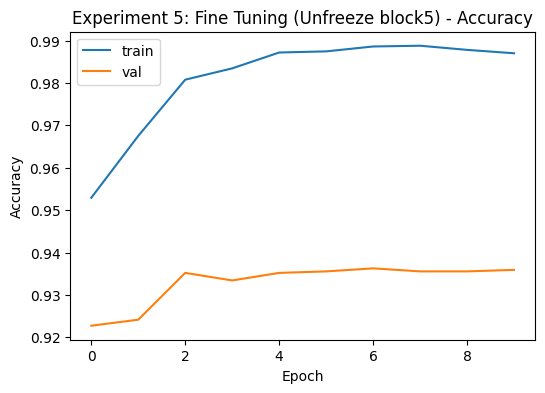

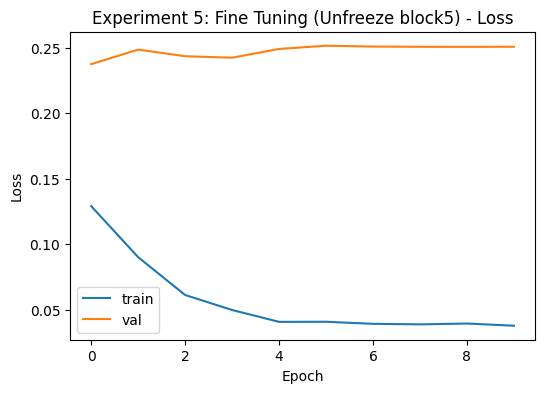


=== Experiment 5: Fine Tuning (block5) ===
Train accuracy: 0.9888 | Validation accuracy: 0.9363 | Test accuracy: 0.9260 | Test loss: 0.2601


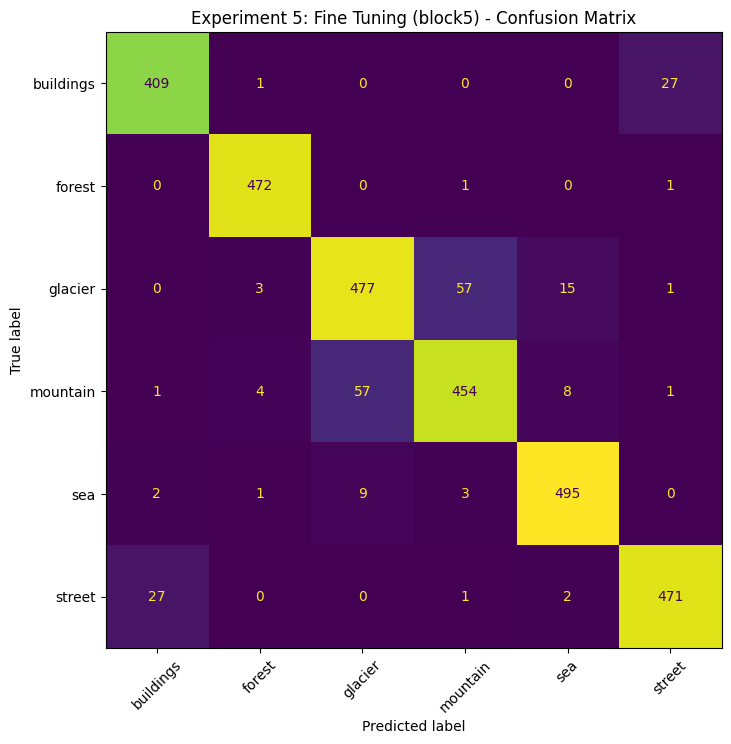


Classification report:

              precision    recall  f1-score   support

   buildings       0.93      0.94      0.93       437
      forest       0.98      1.00      0.99       474
     glacier       0.88      0.86      0.87       553
    mountain       0.88      0.86      0.87       525
         sea       0.95      0.97      0.96       510
      street       0.94      0.94      0.94       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



In [14]:
# 5) Fine Tuning (unfreeze top VGG16 layers + classifier)
model5, base5 = build_vgg16_classifier(NUM_CLASSES, CFG.img_size, base_trainable=False, augment=None)
model5.load_weights('/content/best_exp3_vgg16_frozen.keras')

base5.trainable = True
for layer in base5.layers:
    layer.trainable = layer.name.startswith('block5')

hist5 = compile_and_train(
    model5, train_ds, val_ds, lr=CFG.finetune_lr, epochs=max(10, CFG.epochs), patience=CFG.patience, tag='exp5_finetune'
)
plot_history(hist5, 'Experiment 5: Fine Tuning (Unfreeze block5)')
eval5 = evaluate_model(model5, test_ds, class_names, "Experiment 5: Fine Tuning (block5)", history=hist5)
results.append({'experiment': '5) Fine Tuning', **eval5})


=== Summary (sorted by test_accuracy) ===


,experiment,train_accuracy,validation_accuracy,test_accuracy,test_loss
0,5) Fine Tuning,0.988788,0.936276,0.926000,0.260099
1,3) VGG16 Frozen Base,0.958623,0.926664,0.913667,0.252373
2,4) Feature Extraction,0.959957,0.924528,0.909667,0.255733
3,1) Basic CNN,0.955597,0.839801,0.839667,0.624885
4,2) CNN + Augmentation,0.790443,0.799929,0.812667,0.519870


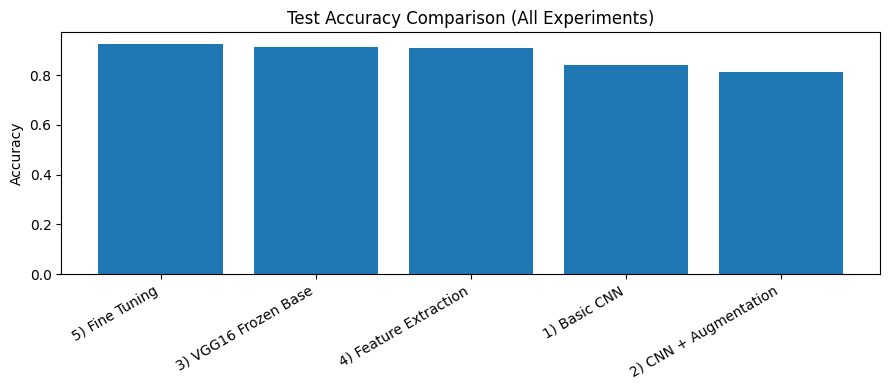

In [15]:
df = pd.DataFrame(results).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
print('\n=== Summary (sorted by test_accuracy) ===')
display(df)

plt.figure(figsize=(9, 4))
plt.bar(df['experiment'], df['test_accuracy'])
plt.xticks(rotation=30, ha='right')
plt.title('Test Accuracy Comparison (All Experiments)')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


In [16]:
# Optional: save summary to Drive
output_csv = '/content/drive/MyDrive/intel_cnn_experiments_summary.csv'
df.to_csv(output_csv, index=False)
print('Saved summary to:', output_csv)


Saved summary to: /content/drive/MyDrive/intel_cnn_experiments_summary.csv
